# 🛍️ Customer Segmentation with RFM Analysis & K-Means Clustering
**Level:** Advanced · **Tools:** Python, Pandas, Scikit-learn (K-Means), Matplotlib/Seaborn

**Business problem:** an online gift retailer based in the UK treats every customer the same. The goal is to segment customers by purchasing behaviour, **Recency, Frequency and Monetary value (RFM)**, so marketing can reward the best customers, win back lapsing ones, and stop overspending on low-value ones.

**Dataset:** [UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail): 541,909 transactions, Dec 2010 – Dec 2011.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110
df = pd.read_csv("data/online_retail.csv.gz", dtype={"InvoiceNo":str,"StockCode":str})
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%m/%d/%Y %H:%M")
print(df.shape); df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 1. Data cleaning

In [2]:
steps = {"raw rows": len(df)}
df = df.dropna(subset=["CustomerID"]);                     steps["with CustomerID"] = len(df)
df = df[~df.InvoiceNo.str.startswith("C")];                steps["excluding cancellations"] = len(df)
df = df[(df.Quantity > 0) & (df.UnitPrice > 0)];            steps["positive qty & price"] = len(df)
df = df.drop_duplicates();                                  steps["deduplicated"] = len(df)
df["CustomerID"] = df.CustomerID.astype(int)
df["Revenue"] = df.Quantity * df.UnitPrice
pd.Series(steps, name="rows").to_frame()

,rows
raw rows,541909
with CustomerID,406829
excluding cancellations,397924
positive qty & price,397884
deduplicated,392692


In [3]:
print(f"Customers: {df.CustomerID.nunique():,} | Invoices: {df.InvoiceNo.nunique():,} | Revenue: £{df.Revenue.sum():,.0f}")
print("Period:", df.InvoiceDate.min().date(), "→", df.InvoiceDate.max().date())

Customers: 4,338 | Invoices: 18,532 | Revenue: £8,887,209
Period: 2010-12-01 → 2011-12-09


## 2. Build the RFM table

In [4]:
snapshot = df.InvoiceDate.max() + pd.Timedelta(days=1)
rfm = df.groupby("CustomerID").agg(Recency=("InvoiceDate", lambda x: (snapshot - x.max()).days),
                                   Frequency=("InvoiceNo","nunique"),
                                   Monetary=("Revenue","sum"))
rfm.describe().round(1)

,Recency,Frequency,Monetary
count,4338.0,4338.0,4338.0
mean,92.5,4.3,2048.7
std,100.0,7.7,8985.2
min,1.0,1.0,3.8
25%,18.0,1.0,306.5
50%,51.0,2.0,668.6
75%,142.0,5.0,1660.6
max,374.0,209.0,280206.0


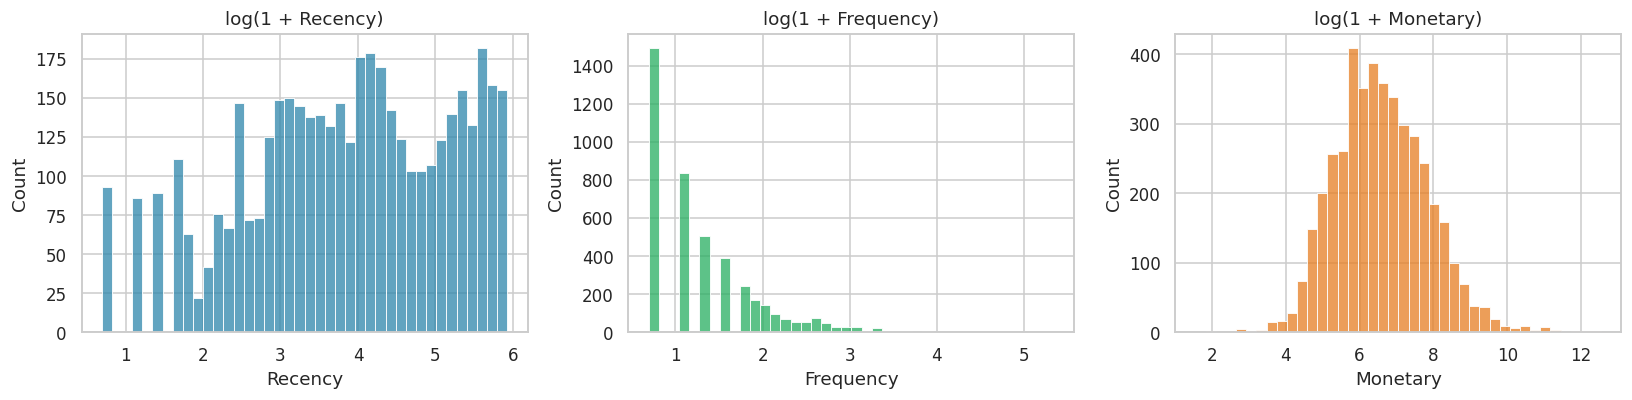

In [5]:
fig, axes = plt.subplots(1,3, figsize=(15,3.8))
for ax, c, col in zip(axes, rfm.columns, ["#2E86AB","#27AE60","#E67E22"]):
    sns.histplot(np.log1p(rfm[c]), ax=ax, color=col, bins=40); ax.set_title(f"log(1 + {c})")
plt.tight_layout(); plt.savefig("images/rfm_distributions.png", bbox_inches="tight"); plt.show()

## 3. Approach A: rule-based RFM scoring
Each customer gets a 1–5 score on R, F and M (quintiles), and the scores map to named segments.

In [6]:
rfm["R"] = pd.qcut(rfm.Recency, 5, labels=[5,4,3,2,1]).astype(int)
rfm["F"] = pd.qcut(rfm.Frequency.rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M"] = pd.qcut(rfm.Monetary, 5, labels=[1,2,3,4,5]).astype(int)
def segment(r):
    if r.R >= 4 and r.F >= 4: return "Champions"
    if r.R >= 3 and r.F >= 3: return "Loyal Customers"
    if r.R >= 4 and r.F <= 2: return "New / Promising"
    if r.R <= 2 and r.F >= 4: return "Can't Lose Them"
    if r.R <= 2 and r.F >= 2: return "At Risk"
    if r.R == 3 and r.F <= 2: return "Need Attention"
    return "Hibernating / Lost"
rfm["Segment"] = rfm.apply(segment, axis=1)
seg = rfm.groupby("Segment").agg(Customers=("R","size"), AvgRecency=("Recency","mean"), AvgFrequency=("Frequency","mean"),
                                 AvgMonetary=("Monetary","mean"), Revenue=("Monetary","sum")).sort_values("Revenue", ascending=False)
seg["%Customers"] = (seg.Customers/seg.Customers.sum()*100).round(1); seg["%Revenue"] = (seg.Revenue/seg.Revenue.sum()*100).round(1)
seg.round(1)

,Customers,AvgRecency,AvgFrequency,AvgMonetary,Revenue,%Customers,%Revenue
Segment,,,,,,,
Champions,1139,13.3,10.0,5191.8,5913422.1,26.3,66.5
Loyal Customers,821,38.0,3.6,1645.7,1351084.3,18.9,15.2
At Risk,870,192.8,1.7,683.0,594183.3,20.1,6.7
Can't Lose Them,275,137.1,4.9,1569.6,431639.3,6.3,4.9
Hibernating / Lost,563,221.9,1.0,516.1,290552.0,13.0,3.3
Need Attention,351,53.5,1.2,459.0,161108.1,8.1,1.8
New / Promising,319,18.5,1.2,455.2,145219.7,7.4,1.6


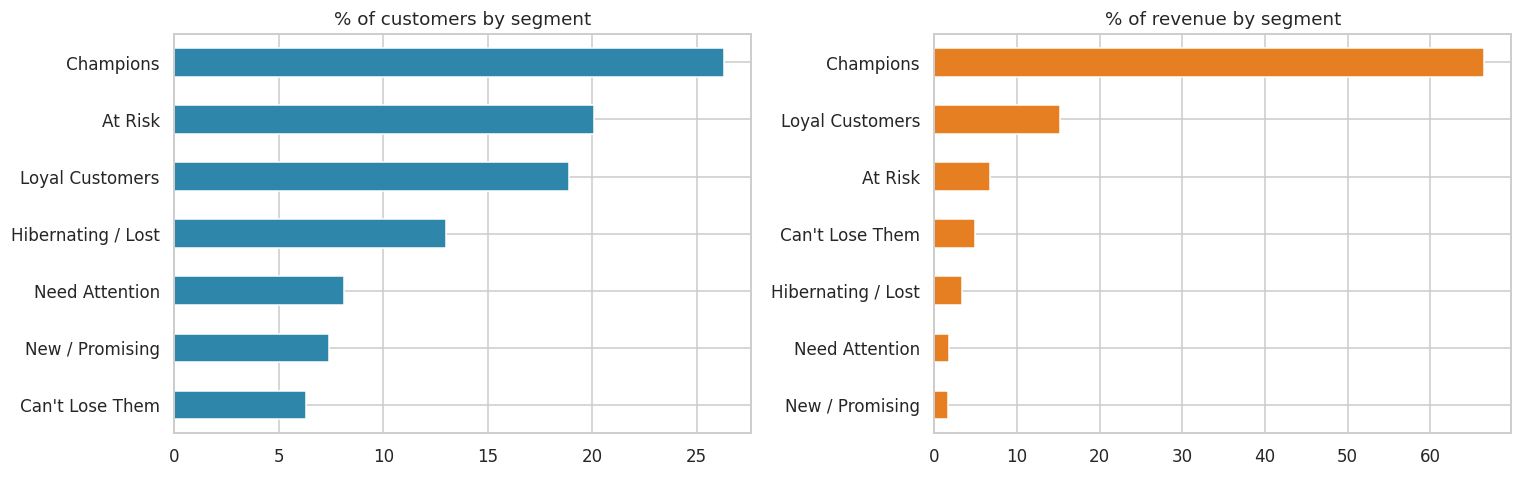

In [7]:
fig, ax = plt.subplots(1,2, figsize=(14,4.5))
seg["%Customers"].sort_values().plot.barh(ax=ax[0], color="#2E86AB", title="% of customers by segment")
seg["%Revenue"].sort_values().plot.barh(ax=ax[1], color="#E67E22", title="% of revenue by segment")
for a in ax: a.set_ylabel("")
plt.tight_layout(); plt.savefig("images/rfm_segments.png", bbox_inches="tight"); plt.show()

## 4. Approach B: K-Means clustering
RFM values are heavily skewed, so they are log-transformed and standardised before clustering. *k* is chosen with the elbow method and the silhouette score.

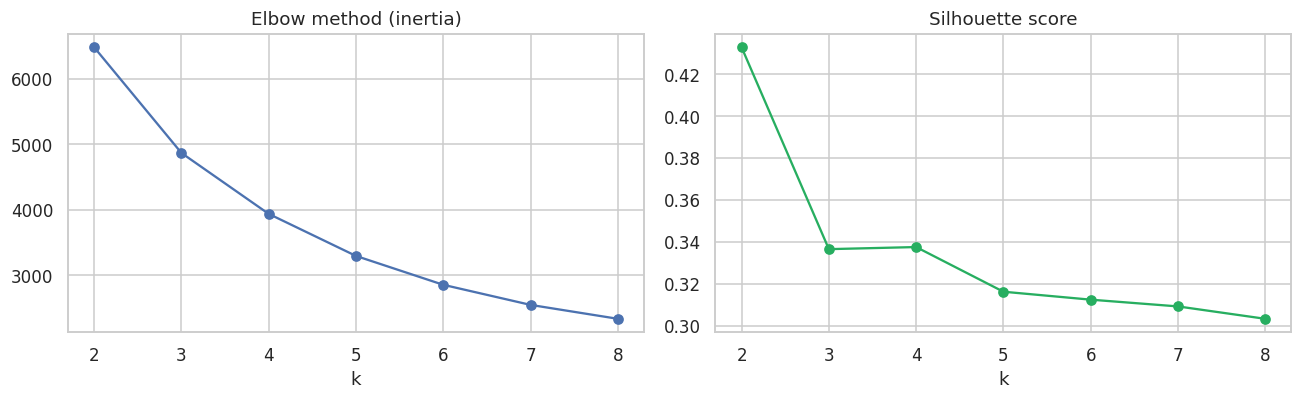

,0,1,2,3,4,5,6
k,2.000,3.000,4.000,5.000,6.000,7.000,8.000
silhouette,0.433,0.337,0.338,0.316,0.312,0.309,0.303


In [8]:
X = StandardScaler().fit_transform(np.log1p(rfm[["Recency","Frequency","Monetary"]]))
ks = range(2, 9); inertia=[]; sil=[]
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertia.append(km.inertia_); sil.append(silhouette_score(X, km.labels_))
fig, ax = plt.subplots(1,2, figsize=(12,3.8))
ax[0].plot(ks, inertia, "o-"); ax[0].set_title("Elbow method (inertia)"); ax[0].set_xlabel("k")
ax[1].plot(ks, sil, "o-", color="#27AE60"); ax[1].set_title("Silhouette score"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.savefig("images/elbow_silhouette.png", bbox_inches="tight"); plt.show()
pd.DataFrame({"k":list(ks),"silhouette":np.round(sil,3)}).T

In [9]:
K = 4  # k=2 has the highest silhouette but only splits "good vs bad"; the elbow flattens after 4 and 4 segments are actionable for marketing
km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X)
rfm["Cluster"] = km.labels_
prof = rfm.groupby("Cluster").agg(Customers=("R","size"), Recency=("Recency","median"), Frequency=("Frequency","median"),
                                  Monetary=("Monetary","median"), Revenue=("Monetary","sum"))
# Name clusters from their profiles: most recent + most frequent = VIP; least recent = Lost;
# of the remaining two, the higher-spending one = Loyal Regulars, the other = New / Recent low-value
vip  = (prof.Recency.rank() + prof.Frequency.rank(ascending=False)).idxmin()
lost = prof.Recency.idxmax()
rest = prof.drop([vip, lost]).sort_values("Monetary", ascending=False).index
names = {vip: "VIP / Champions", lost: "Lost / One-off", rest[0]: "Loyal Regulars", rest[1]: "New / Recent Low-Value"}
rfm["ClusterName"] = rfm.Cluster.map(names); prof.index = prof.index.map(names)
prof["%Customers"] = (prof.Customers/prof.Customers.sum()*100).round(1); prof["%Revenue"] = (prof.Revenue/prof.Revenue.sum()*100).round(1)
prof = prof.sort_values("Revenue", ascending=False); prof.round(1)

,Customers,Recency,Frequency,Monetary,Revenue,%Customers,%Revenue
Cluster,,,,,,,
VIP / Champions,713,8.0,10.0,3722.8,5766757.1,16.4,64.9
Loyal Regulars,1166,57.0,4.0,1345.2,2100873.0,26.9,23.6
Lost / One-off,1622,174.5,1.0,296.1,553099.8,37.4,6.2
New / Recent Low-Value,837,17.0,2.0,480.3,466479.0,19.3,5.2


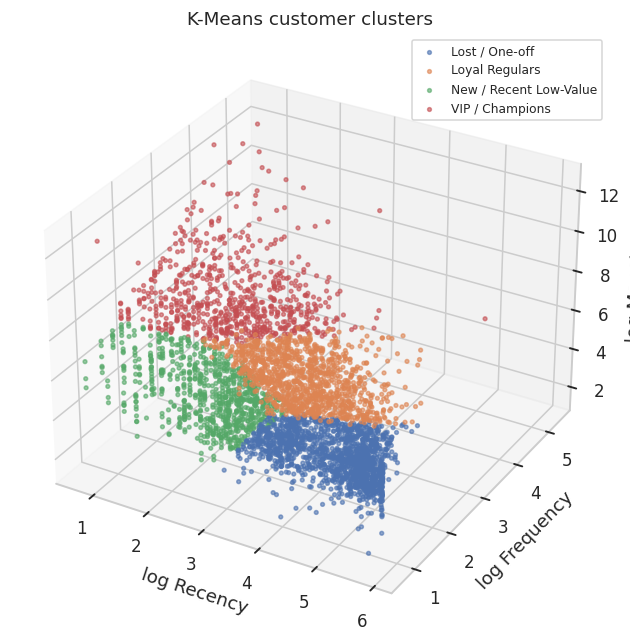

In [10]:
fig = plt.figure(figsize=(8,6)); ax = fig.add_subplot(projection="3d")
for name, g in rfm.groupby("ClusterName"):
    ax.scatter(np.log1p(g.Recency), np.log1p(g.Frequency), np.log1p(g.Monetary), s=6, label=name, alpha=0.6)
ax.set_xlabel("log Recency"); ax.set_ylabel("log Frequency"); ax.set_zlabel("log Monetary"); ax.legend(fontsize=8)
ax.set_title("K-Means customer clusters"); plt.tight_layout(); plt.savefig("images/kmeans_3d.png", bbox_inches="tight"); plt.show()

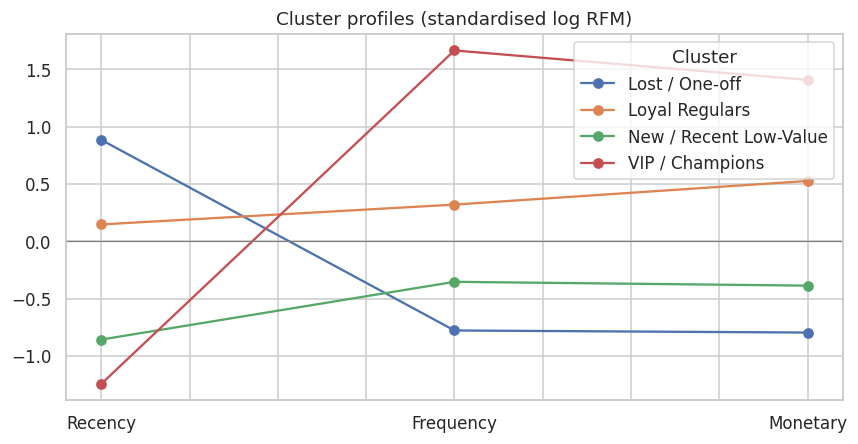

In [11]:
# Snake plot: standardised RFM profile per cluster
z = pd.DataFrame(X, columns=["Recency","Frequency","Monetary"], index=rfm.index).assign(Cluster=rfm.ClusterName)
snake = z.groupby("Cluster").mean().T
ax = snake.plot(marker="o", figsize=(8,4.2), title="Cluster profiles (standardised log RFM)")
ax.axhline(0, color="grey", lw=0.8); plt.tight_layout(); plt.savefig("images/snake_plot.png", bbox_inches="tight"); plt.show()

In [12]:
pd.crosstab(rfm.Segment, rfm.ClusterName)

ClusterName,Lost / One-off,Loyal Regulars,New / Recent Low-Value,VIP / Champions
Segment,,,,
At Risk,708,162,0,0
Can't Lose Them,37,233,0,5
Champions,0,280,184,675
Hibernating / Lost,551,12,0,0
Loyal Customers,52,420,316,33
Need Attention,262,49,40,0
New / Promising,12,10,297,0


In [13]:
rfm.reset_index().to_csv("output/customer_segments.csv", index=False)
print("Saved output/customer_segments.csv:", rfm.shape)

Saved output/customer_segments.csv: (4338, 9)


## 5. Recommendations
| Segment | Strategy |
|---|---|
| VIP / Champions | Loyalty programme, early access, no discounts needed; ask for reviews and referrals |
| Loyal Regulars | Cross-sell and bundles to move them up to VIP; win-back nudges if they go quiet |
| New / Recent Low-Value | Welcome series and a second-purchase incentive to build the habit |
| Lost / One-off | Low-cost automated campaigns only; don't spend heavily on acquisition-style offers |

The rule-based RFM segments and the K-Means clusters broadly agree (see the crosstab). The rule-based version is easier to explain to marketing; K-Means finds the natural groups in the data.